# 02d — Short Peptide Structural and Energetic Ranking

## Obiettivo

Questo notebook prende la libreria generata dal notebook **02c** e valuta i frammenti peptidici naturali corti nel contesto strutturale nativo del complesso **3NJP B–D**.

Il notebook:

1. legge `hotspot_centered_fragment_library.csv`;
2. seleziona un pannello rappresentativo di frammenti di 7, 9, 11, 13 e 15 residui;
3. estrae dal PDB un complesso per ciascun frammento, mantenendo la catena B e la porzione selezionata della catena D;
4. calcola contatti atomici e residuo-residuo;
5. misura quanta parte dell'interfaccia naturale viene coperta;
6. controlla distanze minime e possibili clash;
7. integra opzionalmente **FoldX AnalyseComplex**;
8. produce un ranking strutturale ed energetico preliminare.

## Posizione nella pipeline

```text
01 / 01b → 02b FoldX hotspot → 02c libreria → 02d ranking strutturale/energetico
```

## Interpretazione

Questo notebook analizza i frammenti **nella posa nativa estratta dal PDB**.  
Non dimostra ancora che il peptide isolato mantenga spontaneamente quella conformazione in soluzione. Tale verifica richiederà docking, rilassamento e/o dinamica molecolare.


## 1. Dipendenze

```bash
pip install pandas numpy matplotlib biopython
```

FoldX è opzionale. Se non viene trovato, il notebook completa comunque tutta la parte strutturale e genera uno script per l'esecuzione manuale.


In [1]:
from pathlib import Path
from collections import defaultdict
import json
import math
import os
import re
import shutil
import subprocess
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from Bio.PDB import PDBParser, PDBIO, Select, NeighborSearch, is_aa
except ImportError as exc:
    raise ImportError(
        "Biopython non è installato. Eseguire: pip install biopython"
    ) from exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

print("Ambiente inizializzato correttamente.")

Ambiente inizializzato correttamente.


## 2. Configurazione

La selezione predefinita:

- considera prioritariamente i frammenti interamente compresi nel seed D:21–50;
- prende i migliori frammenti descrittivi per ciascuna lunghezza;
- include un massimo configurabile di candidati;
- conserva almeno un rappresentante per ogni lunghezza disponibile.

È possibile cambiare `TOP_PER_LENGTH` e `MAX_SELECTED_FRAGMENTS`.


In [2]:
PDB_ID = "3NJP"
RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"
SELECTED_CHAINS = [RECEPTOR_CHAIN, PEPTIDE_CHAIN]

# Contatto atomico pesante tra catene
ATOM_CONTACT_CUTOFF_A = 4.5

# Possibile clash severo tra atomi pesanti di catene diverse
SEVERE_CLASH_CUTOFF_A = 2.0
CLOSE_CONTACT_CUTOFF_A = 2.5

# Selezione dei frammenti
PREFER_WITHIN_ORIGINAL_SEED = True
TOP_PER_LENGTH = 3
MAX_SELECTED_FRAGMENTS = 15
REQUIRED_LENGTHS = [7, 9, 11, 13, 15]

# FoldX
RUN_FOLDX_IF_AVAILABLE = True
FOLDX_ANALYSE_CHAINS = f"{RECEPTOR_CHAIN},{PEPTIDE_CHAIN}"

OUTPUT_DIR = Path("outputs")
LIBRARY_DIR = OUTPUT_DIR / "hotspot_centered_library"
RANKING_DIR = OUTPUT_DIR / "short_peptide_structural_ranking"
COMPLEX_DIR = RANKING_DIR / "native_fragment_complexes"
FOLDX_DIR = RANKING_DIR / "foldx_analysecomplex"

for directory in [RANKING_DIR, COMPLEX_DIR, FOLDX_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

LIBRARY_CSV = LIBRARY_DIR / "hotspot_centered_fragment_library.csv"

print("Input libreria:", LIBRARY_CSV.resolve())
print("Output ranking:", RANKING_DIR.resolve())

Input libreria: /Users/robertobruzzese/Desktop/venv/outputs/hotspot_centered_library/hotspot_centered_fragment_library.csv
Output ranking: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking


## 3. Individuazione del PDB 3NJP

Il notebook cerca prima i file già prodotti dalla pipeline. In assenza di un file locale, prova a scaricare 3NJP da RCSB PDB.


In [3]:
candidate_pdb_paths = [
    Path("3njp.pdb"),
    Path("3NJP.pdb"),
    Path("pdb3njp.ent"),
    OUTPUT_DIR / "3njp.pdb",
    OUTPUT_DIR / "3NJP.pdb",
    OUTPUT_DIR / "pdb3njp.ent",
    OUTPUT_DIR / "foldx_buildmodel" / "3NJP_BD_clean.pdb",
    OUTPUT_DIR / "foldx_buildmodel" / "3NJP_BD_clean_Repair.pdb",
    Path("data") / "3njp.pdb",
    Path("data") / "3NJP.pdb",
]

PDB_PATH = next((p for p in candidate_pdb_paths if p.exists()), None)

if PDB_PATH is None:
    PDB_PATH = OUTPUT_DIR / "3NJP.pdb"
    url = "https://files.rcsb.org/download/3NJP.pdb"
    print("PDB locale non trovato. Download da:", url)
    try:
        urllib.request.urlretrieve(url, PDB_PATH)
    except Exception as exc:
        raise FileNotFoundError(
            "Impossibile trovare o scaricare 3NJP.pdb. "
            "Collocare manualmente il file nella cartella corrente o in outputs/."
        ) from exc

print("PDB utilizzato:", PDB_PATH.resolve())

PDB utilizzato: /Users/robertobruzzese/Desktop/venv/outputs/3njp.pdb


## 4. Caricamento della libreria 02c


In [4]:
if not LIBRARY_CSV.exists():
    raise FileNotFoundError(
        f"File mancante: {LIBRARY_CSV}\n"
        "Eseguire prima il notebook 02c nella stessa cartella di lavoro."
    )

library = pd.read_csv(LIBRARY_CSV)

required_columns = {
    "fragment_id", "sequence", "start_resseq", "end_resseq", "length",
    "n_hotspots", "n_interface_residues", "hotspot_density",
    "interface_fraction", "ddG_sum_kcal_mol",
    "descriptive_priority_score", "within_original_seed"
}
missing = required_columns - set(library.columns)
if missing:
    raise ValueError(
        "La libreria 02c non contiene le colonne richieste: "
        + ", ".join(sorted(missing))
    )

for col in [
    "start_resseq", "end_resseq", "length", "n_hotspots",
    "n_interface_residues"
]:
    library[col] = pd.to_numeric(library[col], errors="raise").astype(int)

for col in [
    "hotspot_density", "interface_fraction", "ddG_sum_kcal_mol",
    "descriptive_priority_score"
]:
    library[col] = pd.to_numeric(library[col], errors="coerce")

library["within_original_seed"] = (
    library["within_original_seed"]
    .astype(str)
    .str.lower()
    .map({"true": True, "false": False, "1": True, "0": False})
    .fillna(False)
    .astype(bool)
)

print("Frammenti caricati:", len(library))
print("Lunghezze disponibili:", sorted(library["length"].unique().tolist()))
display(library.head(10))

Frammenti caricati: 71
Lunghezze disponibili: [7, 9, 11, 13, 15]


,fragment_id,chain,start_resseq,start_icode,end_resseq,end_icode,length,sequence,generation_centers,generation_center_resseqs,generation_center_positions_1based,n_generation_centers,hotspot_positions,hotspot_resseqs,n_hotspots,interface_positions,interface_resseqs,n_interface_residues,ddG_sum_kcal_mol,ddG_mean_hotspots_kcal_mol,hotspot_coverage_chain,hotspot_coverage_original_seed,hotspot_density,interface_fraction,within_original_seed,requested_length,contains_center_hotspot,is_truncated,source_type,descriptive_priority_score,start_chain_index,end_chain_index
0,F0001,D,37,NaN,49,NaN,13,YIGERCQYRDLKW,D:Q43,43,7,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,37;39;41;43;44;45;47,7,D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47;D:K48;D:W49,37;38;39;40;41;43;44;45;46;47;48;49,12,27.68977,3.955681,0.466667,0.636364,0.538462,0.923077,True,13,True,False,natural_centered_window,25.970515,32,44
1,F0002,D,35,NaN,47,NaN,13,VGYIGERCQYRDL,D:R41,41,7,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,37;39;41;43;44;45;47,7,D:V35;D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47,35;37;38;39;40;41;43;44;45;46;47,11,27.68977,3.955681,0.466667,0.636364,0.538462,0.846154,True,13,True,False,natural_centered_window,25.855131,30,42
2,F0003,D,33,NaN,45,NaN,13,CVVGYIGERCQYR,D:G39,39,7,1,D:C33;D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45,33;37;39;41;43;44;45,7,D:C33;D:V35;D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45,33;35;37;38;39;40;41;43;44;45,10,27.05909,3.865584,0.466667,0.636364,0.538462,0.769231,True,13,True,False,natural_centered_window,25.676678,28,40
3,F0004,D,37,NaN,51,NaN,15,YIGERCQYRDLKWWE,D:Y44,44,8,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,37;39;41;43;44;45;47,7,D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47;D:K48;D:W49;D:W50;D:E51,37;38;39;40;41;43;44;45;46;47;48;49;50;51,14,27.68977,3.955681,0.466667,0.636364,0.466667,0.933333,False,15,True,False,natural_centered_window,25.802310,32,46
4,F0005,D,36,NaN,50,NaN,15,GYIGERCQYRDLKWW,D:Q43,43,8,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,37;39;41;43;44;45;47,7,D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47;D:K48;D:W49;D:W50,37;38;39;40;41;43;44;45;46;47;48;49;50,13,27.68977,3.955681,0.466667,0.636364,0.466667,0.866667,True,15,True,False,natural_centered_window,25.702310,31,45
5,F0006,D,34,NaN,48,NaN,15,VVGYIGERCQYRDLK,D:R41,41,8,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,37;39;41;43;44;45;47,7,D:V35;D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47;D:K48,35;37;38;39;40;41;43;44;45;46;47;48,12,27.68977,3.955681,0.466667,0.636364,0.466667,0.800000,True,15,True,False,natural_centered_window,25.602310,29,43
6,F0007,D,32,NaN,46,NaN,15,NCVVGYIGERCQYRD,D:G39,39,8,1,D:C33;D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45,33;37;39;41;43;44;45,7,D:N32;D:C33;D:V35;D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46,32;33;35;37;38;39;40;41;43;44;45;46,12,27.05909,3.865584,0.466667,0.636364,0.466667,0.800000,True,15,True,False,natural_centered_window,25.539242,27,41
7,F0008,D,37,NaN,45,NaN,9,YIGERCQYR,D:R41,41,5,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45,37;39;41;43;44;45,6,D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45,37;38;39;40;41;43;44;45,8,24.14606,4.024343,0.400000,0.545455,0.666667,0.888889,True,9,True,False,natural_centered_window,22.901273,32,40
8,F0009,D,39,NaN,47,NaN,9,GERCQYRDL,D:Q43,43,5,1,D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,39;41;43;44;45;47,6,D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47,39;40;41;43;44;45;46;47,8,23.04391,3.840652,0.400000,0.545455,0.666667,0.888889,True,9,True,False,natural_centered_window,22.791058,34,42
9,F0010,D,38,NaN,48,NaN,11,IGERCQYRDLK,D:Q43,43,6,1,D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,39;41;43;44;45;47,6,D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47;D:K48,38;39;40;41;43;44;45;46;47;48,10,23.04391,3.840652,0.400000,0.545455,0.545455,0.909091,True,11,True,False,natural_centered_window,22.538936,33,43


## 5. Selezione del pannello rappresentativo

La selezione non è ancora un verdetto biologico. Serve a limitare l'analisi energetica a un insieme gestibile e diversificato.

Criteri:

1. preferenza per frammenti interamente nel seed originale;
2. miglior punteggio descrittivo;
3. rappresentanza di tutte le lunghezze;
4. rimozione di sequenze duplicate.


In [5]:
selection_pool = library.copy()

if PREFER_WITHIN_ORIGINAL_SEED:
    seed_pool = selection_pool[selection_pool["within_original_seed"]].copy()
    if not seed_pool.empty:
        selection_pool = seed_pool
    else:
        warnings.warn(
            "Nessun frammento interamente nel seed: uso dell'intera libreria."
        )

selected_parts = []

for length in REQUIRED_LENGTHS:
    group = selection_pool[selection_pool["length"] == length].copy()
    if group.empty:
        continue

    group = group.sort_values(
        [
            "descriptive_priority_score",
            "n_hotspots",
            "hotspot_density",
            "interface_fraction",
        ],
        ascending=[False, False, False, False],
    )

    selected_parts.append(group.head(TOP_PER_LENGTH))

if not selected_parts:
    raise ValueError("Nessun frammento selezionabile.")

selected = pd.concat(selected_parts, ignore_index=True)
selected = (
    selected
    .sort_values(
        ["descriptive_priority_score", "n_hotspots", "length"],
        ascending=[False, False, True],
    )
    .drop_duplicates("sequence")
    .head(MAX_SELECTED_FRAGMENTS)
    .reset_index(drop=True)
)

selected["selection_order"] = np.arange(1, len(selected) + 1)

print("Frammenti selezionati:", len(selected))
display(
    selected[
        [
            "selection_order", "fragment_id", "sequence",
            "start_resseq", "end_resseq", "length",
            "n_hotspots", "n_interface_residues",
            "hotspot_density", "interface_fraction",
            "ddG_sum_kcal_mol", "within_original_seed",
            "descriptive_priority_score",
        ]
    ]
)

Frammenti selezionati: 15


,selection_order,fragment_id,sequence,start_resseq,end_resseq,length,n_hotspots,n_interface_residues,hotspot_density,interface_fraction,ddG_sum_kcal_mol,within_original_seed,descriptive_priority_score
0,1,F0001,YIGERCQYRDLKW,37,49,13,7,12,0.538462,0.923077,27.68977,True,25.970515
1,2,F0002,VGYIGERCQYRDL,35,47,13,7,11,0.538462,0.846154,27.68977,True,25.855131
2,3,F0005,GYIGERCQYRDLKWW,36,50,15,7,13,0.466667,0.866667,27.68977,True,25.702310
3,4,F0003,CVVGYIGERCQYR,33,45,13,7,10,0.538462,0.769231,27.05909,True,25.676678
4,5,F0006,VVGYIGERCQYRDLK,34,48,15,7,12,0.466667,0.800000,27.68977,True,25.602310
5,6,F0007,NCVVGYIGERCQYRD,32,46,15,7,12,0.466667,0.800000,27.05909,True,25.539242
6,7,F0008,YIGERCQYR,37,45,9,6,8,0.666667,0.888889,24.14606,True,22.901273
7,8,F0009,GERCQYRDL,39,47,9,6,8,0.666667,0.888889,23.04391,True,22.791058
8,9,F0010,IGERCQYRDLK,38,48,11,6,10,0.545455,0.909091,23.04391,True,22.538936
9,10,F0011,GERCQYRDLKW,39,49,11,6,10,0.545455,0.909091,23.04391,True,22.538936


## 6. Lettura della struttura e controllo delle catene


In [6]:
parser = PDBParser(QUIET=True)
structure = parser.get_structure(PDB_ID, str(PDB_PATH))
model = next(structure.get_models())

available_chains = [chain.id for chain in model]

for chain_id in SELECTED_CHAINS:
    if chain_id not in available_chains:
        raise KeyError(
            f"Catena {chain_id} non presente. Catene disponibili: {available_chains}"
        )

print("Catene disponibili:", available_chains)
print("Catene analizzate:", SELECTED_CHAINS)

Catene disponibili: ['A', 'B', 'C', 'D']
Catene analizzate: ['B', 'D']


## 7. Funzioni strutturali

Le analisi usano solo atomi pesanti.

Per ogni frammento vengono calcolati:

- numero di coppie atomiche entro 4,5 Å;
- numero di contatti residuo-residuo;
- residui della catena B contattati;
- residui del peptide che contattano B;
- distanza intercatena minima;
- numero di coppie sotto 2,5 Å;
- numero di clash severi sotto 2,0 Å.


In [7]:
def heavy_atoms_from_residues(residues):
    atoms = []
    for residue in residues:
        for atom in residue.get_atoms():
            element = (atom.element or "").strip().upper()
            if element != "H":
                atoms.append(atom)
    return atoms


def standard_residues(chain):
    return [
        residue for residue in chain
        if is_aa(residue, standard=True)
    ]


def residue_label(residue, chain_id):
    _, resseq, icode = residue.id
    return f"{chain_id}:{residue.get_resname()}{int(resseq)}{str(icode).strip()}"


def residue_key(residue, chain_id):
    _, resseq, icode = residue.id
    return (chain_id, int(resseq), str(icode).strip())


def fragment_residues_from_row(model, row):
    peptide_chain = model[PEPTIDE_CHAIN]
    start = int(row["start_resseq"])
    end = int(row["end_resseq"])

    residues = [
        residue for residue in standard_residues(peptide_chain)
        if start <= int(residue.id[1]) <= end
    ]

    if len(residues) != int(row["length"]):
        raise ValueError(
            f"{row['fragment_id']}: attesi {row['length']} residui, "
            f"trovati {len(residues)} nell'intervallo {start}-{end}."
        )

    return residues


def interchain_contact_metrics(receptor_residues, peptide_residues):
    receptor_atoms = heavy_atoms_from_residues(receptor_residues)
    peptide_atoms = heavy_atoms_from_residues(peptide_residues)

    if not receptor_atoms or not peptide_atoms:
        raise ValueError("Lista di atomi vuota.")

    receptor_search = NeighborSearch(receptor_atoms)

    atom_pairs = []
    residue_pairs = set()
    receptor_contact_residues = set()
    peptide_contact_residues = set()
    close_pairs = 0
    severe_clashes = 0
    min_distance = float("inf")

    for pep_atom in peptide_atoms:
        neighbors = receptor_search.search(
            pep_atom.coord,
            ATOM_CONTACT_CUTOFF_A,
            level="A",
        )

        for rec_atom in neighbors:
            distance = float(np.linalg.norm(pep_atom.coord - rec_atom.coord))
            min_distance = min(min_distance, distance)

            rec_res = rec_atom.get_parent()
            pep_res = pep_atom.get_parent()

            rec_key = residue_key(rec_res, RECEPTOR_CHAIN)
            pep_key = residue_key(pep_res, PEPTIDE_CHAIN)

            atom_pairs.append((rec_atom, pep_atom, distance))
            residue_pairs.add((rec_key, pep_key))
            receptor_contact_residues.add(rec_key)
            peptide_contact_residues.add(pep_key)

            if distance < CLOSE_CONTACT_CUTOFF_A:
                close_pairs += 1
            if distance < SEVERE_CLASH_CUTOFF_A:
                severe_clashes += 1

    if math.isinf(min_distance):
        # Calcolo esplicito della minima distanza se nessuna coppia è entro 4,5 Å
        for pep_atom in peptide_atoms:
            for rec_atom in receptor_atoms:
                distance = float(np.linalg.norm(pep_atom.coord - rec_atom.coord))
                min_distance = min(min_distance, distance)

    return {
        "n_atom_contacts_4p5A": int(len(atom_pairs)),
        "n_residue_contacts_4p5A": int(len(residue_pairs)),
        "n_receptor_contact_residues": int(len(receptor_contact_residues)),
        "n_peptide_contact_residues": int(len(peptide_contact_residues)),
        "peptide_contact_residue_fraction": (
            len(peptide_contact_residues) / len(peptide_residues)
            if peptide_residues else np.nan
        ),
        "min_interchain_distance_A": float(min_distance),
        "n_close_pairs_below_2p5A": int(close_pairs),
        "n_severe_clashes_below_2p0A": int(severe_clashes),
        "residue_contact_pairs": residue_pairs,
        "receptor_contact_residues": receptor_contact_residues,
        "peptide_contact_residues": peptide_contact_residues,
    }


receptor_residues = standard_residues(model[RECEPTOR_CHAIN])
full_peptide_residues = standard_residues(model[PEPTIDE_CHAIN])

full_interface_metrics = interchain_contact_metrics(
    receptor_residues,
    full_peptide_residues,
)

print("Contatti residuo-residuo B–D completi:",
      full_interface_metrics["n_residue_contacts_4p5A"])
print("Contatti atomici B–D completi:",
      full_interface_metrics["n_atom_contacts_4p5A"])

Contatti residuo-residuo B–D completi: 88
Contatti atomici B–D completi: 440


## 8. Riferimento: seed originale D:21–50

La copertura di ciascun frammento viene confrontata sia con l'intera catena D sia con il seed originale.


In [8]:
ORIGINAL_SEED_START = 21
ORIGINAL_SEED_END = 50

seed_residues = [
    residue for residue in full_peptide_residues
    if ORIGINAL_SEED_START <= int(residue.id[1]) <= ORIGINAL_SEED_END
]

seed_interface_metrics = interchain_contact_metrics(
    receptor_residues,
    seed_residues,
)

print("Residui nel seed:", len(seed_residues))
print("Contatti residuo-residuo del seed:",
      seed_interface_metrics["n_residue_contacts_4p5A"])
print("Contatti atomici del seed:",
      seed_interface_metrics["n_atom_contacts_4p5A"])

Residui nel seed: 30
Contatti residuo-residuo del seed: 68
Contatti atomici del seed: 345


## 9. Estrazione dei complessi nativi

Ogni file contiene:

- tutti i residui standard della catena B;
- solo i residui della catena D compresi nel frammento;
- le coordinate native del PDB.

Questi file saranno usati anche da FoldX.


In [9]:
class FragmentComplexSelect(Select):
    def __init__(
        self,
        receptor_chain,
        peptide_chain,
        peptide_start,
        peptide_end,
    ):
        self.receptor_chain = receptor_chain
        self.peptide_chain = peptide_chain
        self.peptide_start = int(peptide_start)
        self.peptide_end = int(peptide_end)

    def accept_chain(self, chain):
        return int(chain.id in {self.receptor_chain, self.peptide_chain})

    def accept_residue(self, residue):
        chain_id = residue.get_parent().id

        if not is_aa(residue, standard=True):
            return 0

        if chain_id == self.receptor_chain:
            return 1

        if chain_id == self.peptide_chain:
            resseq = int(residue.id[1])
            return int(self.peptide_start <= resseq <= self.peptide_end)

        return 0


pdb_io = PDBIO()
pdb_io.set_structure(structure)

complex_paths = {}

for row in selected.itertuples(index=False):
    filename = (
        f"{row.fragment_id}_{RECEPTOR_CHAIN}{PEPTIDE_CHAIN}_"
        f"D{int(row.start_resseq)}-{int(row.end_resseq)}.pdb"
    )
    path = COMPLEX_DIR / filename

    selector = FragmentComplexSelect(
        receptor_chain=RECEPTOR_CHAIN,
        peptide_chain=PEPTIDE_CHAIN,
        peptide_start=row.start_resseq,
        peptide_end=row.end_resseq,
    )

    pdb_io.save(str(path), select=selector)
    complex_paths[row.fragment_id] = path

print("Complessi estratti:", len(complex_paths))
for fragment_id, path in list(complex_paths.items())[:5]:
    print(fragment_id, "→", path.resolve())

Complessi estratti: 15
F0001 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0001_BD_D37-49.pdb
F0002 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0002_BD_D35-47.pdb
F0005 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0005_BD_D36-50.pdb
F0003 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0003_BD_D33-45.pdb
F0006 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0006_BD_D34-48.pdb


## 10. Calcolo delle metriche strutturali


In [10]:
structural_rows = []

full_residue_pairs = full_interface_metrics["residue_contact_pairs"]
seed_residue_pairs = seed_interface_metrics["residue_contact_pairs"]

for row in selected.itertuples(index=False):
    fragment_residues = fragment_residues_from_row(model, row._asdict())

    metrics = interchain_contact_metrics(
        receptor_residues,
        fragment_residues,
    )

    fragment_pairs = metrics["residue_contact_pairs"]

    structural_rows.append({
        "fragment_id": row.fragment_id,
        "complex_pdb": str(complex_paths[row.fragment_id]),
        "n_atom_contacts_4p5A": metrics["n_atom_contacts_4p5A"],
        "n_residue_contacts_4p5A": metrics["n_residue_contacts_4p5A"],
        "n_receptor_contact_residues": metrics["n_receptor_contact_residues"],
        "n_peptide_contact_residues": metrics["n_peptide_contact_residues"],
        "peptide_contact_residue_fraction": metrics[
            "peptide_contact_residue_fraction"
        ],
        "full_D_residue_contact_coverage": (
            len(fragment_pairs & full_residue_pairs) / len(full_residue_pairs)
            if full_residue_pairs else np.nan
        ),
        "seed_residue_contact_coverage": (
            len(fragment_pairs & seed_residue_pairs) / len(seed_residue_pairs)
            if seed_residue_pairs else np.nan
        ),
        "min_interchain_distance_A": metrics["min_interchain_distance_A"],
        "n_close_pairs_below_2p5A": metrics[
            "n_close_pairs_below_2p5A"
        ],
        "n_severe_clashes_below_2p0A": metrics[
            "n_severe_clashes_below_2p0A"
        ],
        "structural_status": (
            "SEVERE_CLASH"
            if metrics["n_severe_clashes_below_2p0A"] > 0
            else "NATIVE_GEOMETRY_OK"
        ),
        "contact_pair_labels": ";".join(
            sorted(
                f"{a[0]}:{a[1]}{a[2]}-{b[0]}:{b[1]}{b[2]}"
                for a, b in fragment_pairs
            )
        ),
    })

structural_metrics = pd.DataFrame(structural_rows)

ranking = selected.merge(
    structural_metrics,
    on="fragment_id",
    how="left",
)

display(
    ranking[
        [
            "fragment_id", "sequence", "length",
            "n_hotspots", "n_atom_contacts_4p5A",
            "n_residue_contacts_4p5A",
            "n_peptide_contact_residues",
            "peptide_contact_residue_fraction",
            "seed_residue_contact_coverage",
            "full_D_residue_contact_coverage",
            "min_interchain_distance_A",
            "n_severe_clashes_below_2p0A",
            "structural_status",
        ]
    ]
)

,fragment_id,sequence,length,n_hotspots,n_atom_contacts_4p5A,n_residue_contacts_4p5A,n_peptide_contact_residues,peptide_contact_residue_fraction,seed_residue_contact_coverage,full_D_residue_contact_coverage,min_interchain_distance_A,n_severe_clashes_below_2p0A,structural_status
0,F0001,YIGERCQYRDLKW,13,7,223,41,12,0.923077,0.602941,0.465909,2.602119,0,NATIVE_GEOMETRY_OK
1,F0002,VGYIGERCQYRDL,13,7,176,37,11,0.846154,0.544118,0.420455,2.602119,0,NATIVE_GEOMETRY_OK
2,F0005,GYIGERCQYRDLKWW,15,7,224,42,13,0.866667,0.617647,0.477273,2.602119,0,NATIVE_GEOMETRY_OK
3,F0003,CVVGYIGERCQYR,13,7,148,31,10,0.769231,0.455882,0.352273,2.602119,0,NATIVE_GEOMETRY_OK
4,F0006,VVGYIGERCQYRDLK,15,7,192,40,12,0.800000,0.588235,0.454545,2.602119,0,NATIVE_GEOMETRY_OK
5,F0007,NCVVGYIGERCQYRD,15,7,174,35,12,0.800000,0.514706,0.397727,2.602119,0,NATIVE_GEOMETRY_OK
6,F0008,YIGERCQYR,9,6,125,26,8,0.888889,0.382353,0.295455,2.602119,0,NATIVE_GEOMETRY_OK
7,F0009,GERCQYRDL,9,6,160,31,8,0.888889,0.455882,0.352273,2.602119,0,NATIVE_GEOMETRY_OK
8,F0010,IGERCQYRDLK,11,6,185,37,10,0.909091,0.544118,0.420455,2.602119,0,NATIVE_GEOMETRY_OK
9,F0011,GERCQYRDLKW,11,6,212,36,10,0.909091,0.529412,0.409091,2.602119,0,NATIVE_GEOMETRY_OK


## 11. Densità di contatto

Per confrontare peptidi di lunghezza diversa vengono calcolati anche:

- contatti atomici per residuo;
- contatti residuo-residuo per residuo;
- hotspot per residuo;
- ΔΔG alanine-scanning cumulativo per residuo.


In [11]:
ranking["atom_contacts_per_residue"] = (
    ranking["n_atom_contacts_4p5A"] / ranking["length"]
)
ranking["residue_contacts_per_residue"] = (
    ranking["n_residue_contacts_4p5A"] / ranking["length"]
)
ranking["ddG_hotspot_sum_per_residue"] = (
    ranking["ddG_sum_kcal_mol"] / ranking["length"]
)
ranking["is_clash_free"] = (
    ranking["n_severe_clashes_below_2p0A"] == 0
)

display(
    ranking[
        [
            "fragment_id", "sequence", "length",
            "atom_contacts_per_residue",
            "residue_contacts_per_residue",
            "hotspot_density",
            "ddG_hotspot_sum_per_residue",
            "interface_fraction",
            "is_clash_free",
        ]
    ].sort_values(
        ["residue_contacts_per_residue", "hotspot_density"],
        ascending=False,
    )
)

,fragment_id,sequence,length,atom_contacts_per_residue,residue_contacts_per_residue,hotspot_density,ddG_hotspot_sum_per_residue,interface_fraction,is_clash_free
11,F0017,RCQYRDL,7,16.714286,3.571429,0.714286,2.452474,0.857143,True
12,F0018,ERCQYRDLK,9,18.111111,3.555556,0.555556,1.907480,0.888889,True
7,F0009,GERCQYRDL,9,17.777778,3.444444,0.666667,2.560434,0.888889,True
8,F0010,IGERCQYRDLK,11,16.818182,3.363636,0.545455,2.094901,0.909091,True
9,F0011,GERCQYRDLKW,11,19.272727,3.272727,0.545455,2.094901,0.909091,True
0,F0001,YIGERCQYRDLKW,13,17.153846,3.153846,0.538462,2.129982,0.923077,True
13,F0029,IGERCQY,7,15.857143,3.000000,0.571429,2.499627,0.857143,True
14,F0030,ERCQYRD,7,15.000000,3.000000,0.571429,1.946230,0.857143,True
6,F0008,YIGERCQYR,9,13.888889,2.888889,0.666667,2.682896,0.888889,True
1,F0002,VGYIGERCQYRDL,13,13.538462,2.846154,0.538462,2.129982,0.846154,True


## 12. Individuazione di FoldX

Il notebook cerca:

1. `foldx` nel PATH;
2. il percorso già usato nei notebook precedenti su macOS;
3. alcuni nomi comuni del binario.

Se FoldX non viene trovato, la parte strutturale resta valida e viene creato uno script `.sh`.


In [12]:
foldx_candidates = [
    shutil.which("foldx"),
    shutil.which("FoldX"),
    "/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx",
    "/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/FoldX",
    str(Path.home() / "Downloads" / "foldx5_MacSilicon_0" / "foldx"),
    str(Path.home() / "Downloads" / "foldx5_MacSilicon_0" / "FoldX"),
]

FOLDX_EXECUTABLE = None

for candidate in foldx_candidates:
    if candidate and Path(candidate).exists():
        FOLDX_EXECUTABLE = str(Path(candidate).resolve())
        break

FOLDX_AVAILABLE = FOLDX_EXECUTABLE is not None

print("FoldX disponibile:", FOLDX_AVAILABLE)
print("Eseguibile:", FOLDX_EXECUTABLE)

FoldX disponibile: True
Eseguibile: /Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231


## 13. Preparazione dei comandi FoldX AnalyseComplex

FoldX viene eseguito sui complessi estratti nella posa nativa.

Il risultato di `AnalyseComplex` è uno score energetico preliminare del complesso estratto, non un test di stabilità del peptide isolato.


In [13]:
commands = [
    "#!/usr/bin/env bash",
    "set -e",
    "",
]

if FOLDX_EXECUTABLE:
    commands.append(f'FOLDX="{FOLDX_EXECUTABLE}"')
else:
    commands.append('FOLDX="foldx"')

commands.extend([
    f'WORKDIR="{FOLDX_DIR.resolve()}"',
    'mkdir -p "$WORKDIR"',
    "",
])

for row in selected.itertuples(index=False):
    src = complex_paths[row.fragment_id].resolve()
    dst_name = src.name

    commands.append(f'cp "{src}" "$WORKDIR/{dst_name}"')
    commands.append(
        f'cd "$WORKDIR" && "$FOLDX" '
        f'--command=AnalyseComplex '
        f'--pdb="{dst_name}" '
        f'--analyseComplexChains={FOLDX_ANALYSE_CHAINS}'
    )
    commands.append("")

FOLDX_SCRIPT = RANKING_DIR / "run_foldx_analysecomplex.sh"
FOLDX_SCRIPT.write_text("\n".join(commands) + "\n", encoding="utf-8")
FOLDX_SCRIPT.chmod(0o755)

print("Script salvato:", FOLDX_SCRIPT.resolve())
print()
print(FOLDX_SCRIPT.read_text(encoding="utf-8")[:3000])

Script salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/run_foldx_analysecomplex.sh

#!/usr/bin/env bash
set -e

FOLDX="/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231"
WORKDIR="/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/foldx_analysecomplex"
mkdir -p "$WORKDIR"

cp "/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0001_BD_D37-49.pdb" "$WORKDIR/F0001_BD_D37-49.pdb"
cd "$WORKDIR" && "$FOLDX" --command=AnalyseComplex --pdb="F0001_BD_D37-49.pdb" --analyseComplexChains=B,D

cp "/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F0002_BD_D35-47.pdb" "$WORKDIR/F0002_BD_D35-47.pdb"
cd "$WORKDIR" && "$FOLDX" --command=AnalyseComplex --pdb="F0002_BD_D35-47.pdb" --analyseComplexChains=B,D

cp "/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes/F00

## 14. Esecuzione automatica opzionale di FoldX

L'esecuzione avviene solo se:

```python
RUN_FOLDX_IF_AVAILABLE = True
```

e il binario è stato trovato.

Gli errori di un singolo frammento vengono registrati senza interrompere l'intera analisi.


In [14]:
foldx_run_rows = []

if RUN_FOLDX_IF_AVAILABLE and FOLDX_AVAILABLE:
    for row in selected.itertuples(index=False):
        source_pdb = complex_paths[row.fragment_id]
        target_pdb = FOLDX_DIR / source_pdb.name

        shutil.copy2(source_pdb, target_pdb)

        command = [
            FOLDX_EXECUTABLE,
            "--command=AnalyseComplex",
            f"--pdb={target_pdb.name}",
            f"--analyseComplexChains={FOLDX_ANALYSE_CHAINS}",
        ]

        print("FoldX:", row.fragment_id)

        result = subprocess.run(
            command,
            cwd=FOLDX_DIR,
            capture_output=True,
            text=True,
            check=False,
        )

        foldx_run_rows.append({
            "fragment_id": row.fragment_id,
            "returncode": int(result.returncode),
            "stdout": result.stdout[-4000:],
            "stderr": result.stderr[-4000:],
        })

        if result.returncode != 0:
            print("  ERRORE:", result.stderr[-500:])
        else:
            print("  completato")
else:
    print(
        "FoldX non eseguito automaticamente. "
        "Usare lo script:", FOLDX_SCRIPT.resolve()
    )

foldx_runs = pd.DataFrame(foldx_run_rows)

if not foldx_runs.empty:
    display(foldx_runs[["fragment_id", "returncode"]])

FoldX: F0001
  completato
FoldX: F0002
  completato
FoldX: F0005
  completato
FoldX: F0003
  completato
FoldX: F0006
  completato
FoldX: F0007
  completato
FoldX: F0008
  completato
FoldX: F0009
  completato
FoldX: F0010
  completato
FoldX: F0011
  completato
FoldX: F0012
  completato
FoldX: F0017
  completato
FoldX: F0018
  completato
FoldX: F0029
  completato
FoldX: F0030
  completato


,fragment_id,returncode
0,F0001,0
1,F0002,0
2,F0005,0
3,F0003,0
4,F0006,0
5,F0007,0
6,F0008,0
7,F0009,0
8,F0010,0
9,F0011,0


## 15. Parsing robusto degli output FoldX

FoldX può produrre file con nomi e intestazioni leggermente differenti.  
Il parser cerca i file `Interaction_*.fxout`, identifica la riga relativa al PDB e recupera il valore numerico di interazione.

Quando l'intestazione è disponibile, viene cercata una colonna contenente `Interaction Energy`.


In [15]:
def parse_foldx_interaction_file(path):
    lines = path.read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines()

    lines = [line.strip() for line in lines if line.strip()]

    header = None
    data_lines = []

    for line in lines:
        lower = line.lower()
        if "interaction energy" in lower:
            header = re.split(r"\t+|\s{2,}", line.strip())
            continue

        if line.startswith("#") or line.startswith("Pdb"):
            continue

        if ".pdb" in line or re.match(r"^[A-Za-z0-9_.-]+\s+", line):
            data_lines.append(line)

    if not data_lines:
        return {
            "foldx_interaction_energy_kcal_mol": np.nan,
            "foldx_source_file": str(path),
            "foldx_parse_status": "NO_DATA_LINE",
            "foldx_raw_line": "",
        }

    raw_line = data_lines[-1]
    tokens_tab = [t.strip() for t in raw_line.split("\t") if t.strip()]
    tokens_ws = raw_line.split()
    tokens = tokens_tab if len(tokens_tab) > 1 else tokens_ws

    value = np.nan
    status = "FALLBACK_FIRST_NUMERIC"

    if header and len(header) == len(tokens):
        normalized = [h.lower().replace("_", " ") for h in header]
        candidates = [
            i for i, h in enumerate(normalized)
            if "interaction" in h and "energy" in h
        ]
        if candidates:
            try:
                value = float(tokens[candidates[0]])
                status = "HEADER_MATCH"
            except Exception:
                pass

    if pd.isna(value):
        numeric_values = []
        for token in tokens[1:]:
            try:
                numeric_values.append(float(token))
            except Exception:
                continue

        if numeric_values:
            value = numeric_values[0]
        else:
            status = "NO_NUMERIC_VALUE"

    return {
        "foldx_interaction_energy_kcal_mol": value,
        "foldx_source_file": str(path),
        "foldx_parse_status": status,
        "foldx_raw_line": raw_line,
    }


foldx_energy_rows = []

for row in selected.itertuples(index=False):
    stem = complex_paths[row.fragment_id].stem

    candidate_files = sorted(
        list(FOLDX_DIR.glob(f"Interaction_{stem}*.fxout"))
        + list(FOLDX_DIR.glob(f"*Interaction*{stem}*.fxout"))
    )

    if not candidate_files:
        foldx_energy_rows.append({
            "fragment_id": row.fragment_id,
            "foldx_interaction_energy_kcal_mol": np.nan,
            "foldx_source_file": "",
            "foldx_parse_status": "FILE_NOT_FOUND",
            "foldx_raw_line": "",
        })
        continue

    parsed = parse_foldx_interaction_file(candidate_files[-1])
    parsed["fragment_id"] = row.fragment_id
    foldx_energy_rows.append(parsed)

foldx_energies = pd.DataFrame(foldx_energy_rows)

display(
    foldx_energies[
        [
            "fragment_id",
            "foldx_interaction_energy_kcal_mol",
            "foldx_parse_status",
            "foldx_source_file",
        ]
    ]
)

,fragment_id,foldx_interaction_energy_kcal_mol,foldx_parse_status,foldx_source_file
0,F0001,-5.150880,HEADER_MATCH,outputs/short_peptide_structural_ranking/foldx_analysecomplex/Interaction_F0001_BD_D37-49_AC.fxout
1,F0002,-1.970180,HEADER_MATCH,outputs/short_peptide_structural_ranking/foldx_analysecomplex/Interaction_F0002_BD_D35-47_AC.fxout
2,F0005,-3.913990,HEADER_MATCH,outputs/short_peptide_structural_ranking/foldx_analysecomplex/Interaction_F0005_BD_D36-50_AC.fxout
3,F0003,1.121130,HEADER_MATCH,outputs/short_peptide_structural_ranking/foldx_analysecomplex/Interaction_F0003_BD_D33-45_AC.fxout
4,F0006,-2.421190,HEADER_MATCH,outputs/short_peptide_structural_ranking/foldx_analysecomplex/Interaction_F0006_BD_D34-48_AC.fxout
5,F0007,2.736040,HEADER_MATCH,outputs/short_peptide_structural_ranking/foldx_analysecomplex/Interaction_F0007_BD_D32-46_AC.fxout
6,F0008,0.026411,HEADER_MATCH,outputs/short_peptide_structural_ranking/foldx_analysecomplex/Interaction_F0008_BD_D37-45_AC.fxout
7,F0009,-0.807793,HEADER_MATCH,outputs/short_peptide_structural_ranking/foldx_analysecomplex/Interaction_F0009_BD_D39-47_AC.fxout
8,F0010,-2.944400,HEADER_MATCH,outputs/short_peptide_structural_ranking/foldx_analysecomplex/Interaction_F0010_BD_D38-48_AC.fxout
9,F0011,-2.648450,HEADER_MATCH,outputs/short_peptide_structural_ranking/foldx_analysecomplex/Interaction_F0011_BD_D39-49_AC.fxout


## 16. Costruzione del ranking

Il ranking strutturale privilegia:

- copertura dei contatti del seed;
- densità dei contatti;
- frazione dei residui del peptide che interagisce con B;
- densità degli hotspot;
- assenza di clash severi;
- minore lunghezza, a parità di informazione conservata.

Quando FoldX è disponibile, un'energia di interazione più negativa migliora il ranking.

Il punteggio è uno strumento di priorizzazione, non una misura sperimentale di affinità.


In [16]:
ranking = ranking.merge(
    foldx_energies[
        [
            "fragment_id",
            "foldx_interaction_energy_kcal_mol",
            "foldx_source_file",
            "foldx_parse_status",
        ]
    ],
    on="fragment_id",
    how="left",
)

def minmax(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce")
    valid = s.dropna()

    if valid.empty or valid.max() == valid.min():
        result = pd.Series(0.5, index=s.index, dtype=float)
        result[s.isna()] = 0.0
        return result

    result = (s - valid.min()) / (valid.max() - valid.min())
    if not higher_is_better:
        result = 1.0 - result

    result[s.isna()] = 0.0
    return result


ranking["norm_seed_contact_coverage"] = minmax(
    ranking["seed_residue_contact_coverage"]
)
ranking["norm_residue_contact_density"] = minmax(
    ranking["residue_contacts_per_residue"]
)
ranking["norm_peptide_contact_fraction"] = minmax(
    ranking["peptide_contact_residue_fraction"]
)
ranking["norm_hotspot_density"] = minmax(
    ranking["hotspot_density"]
)
ranking["norm_ddG_density"] = minmax(
    ranking["ddG_hotspot_sum_per_residue"]
)
ranking["norm_shortness"] = minmax(
    ranking["length"],
    higher_is_better=False,
)
ranking["norm_foldx_energy"] = minmax(
    ranking["foldx_interaction_energy_kcal_mol"],
    higher_is_better=False,
)

ranking["clash_penalty"] = np.where(
    ranking["n_severe_clashes_below_2p0A"] > 0,
    1.0,
    0.0,
)

base_score = (
    0.28 * ranking["norm_seed_contact_coverage"]
    + 0.20 * ranking["norm_residue_contact_density"]
    + 0.16 * ranking["norm_peptide_contact_fraction"]
    + 0.14 * ranking["norm_hotspot_density"]
    + 0.10 * ranking["norm_ddG_density"]
    + 0.12 * ranking["norm_shortness"]
    - 0.50 * ranking["clash_penalty"]
)

has_foldx = ranking["foldx_interaction_energy_kcal_mol"].notna()

ranking["structural_priority_score"] = base_score
ranking["final_priority_score"] = np.where(
    has_foldx,
    0.80 * base_score + 0.20 * ranking["norm_foldx_energy"],
    base_score,
)

ranking = (
    ranking
    .sort_values(
        [
            "final_priority_score",
            "seed_residue_contact_coverage",
            "n_hotspots",
            "length",
        ],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)

ranking.insert(
    0,
    "structural_rank",
    np.arange(1, len(ranking) + 1),
)

ranking["recommended_for_next_stage"] = (
    (ranking["structural_rank"] <= 5)
    & ranking["is_clash_free"]
)

display(
    ranking[
        [
            "structural_rank", "fragment_id", "sequence", "length",
            "n_hotspots", "seed_residue_contact_coverage",
            "residue_contacts_per_residue",
            "peptide_contact_residue_fraction",
            "hotspot_density",
            "ddG_hotspot_sum_per_residue",
            "foldx_interaction_energy_kcal_mol",
            "n_severe_clashes_below_2p0A",
            "structural_priority_score",
            "final_priority_score",
            "recommended_for_next_stage",
        ]
    ]
)

,structural_rank,fragment_id,sequence,length,n_hotspots,seed_residue_contact_coverage,residue_contacts_per_residue,peptide_contact_residue_fraction,hotspot_density,ddG_hotspot_sum_per_residue,foldx_interaction_energy_kcal_mol,n_severe_clashes_below_2p0A,structural_priority_score,final_priority_score,recommended_for_next_stage
0,1,F0001,YIGERCQYRDLKW,13,7,0.602941,3.153846,0.923077,0.538462,2.129982,-5.150880,0,0.666897,0.733518,True
1,2,F0010,IGERCQYRDLK,11,6,0.544118,3.363636,0.909091,0.545455,2.094901,-2.944400,0,0.662870,0.674343,True
2,3,F0009,GERCQYRDL,9,6,0.455882,3.444444,0.888889,0.666667,2.560434,-0.807793,0,0.726409,0.670994,True
3,4,F0017,RCQYRDL,7,5,0.367647,3.571429,0.857143,0.714286,2.452474,-2.026120,0,0.678547,0.663598,True
4,5,F0011,GERCQYRDLKW,11,6,0.529412,3.272727,0.909091,0.545455,2.094901,-2.648450,0,0.634851,0.644423,True
5,6,F0018,ERCQYRDLK,9,5,0.470588,3.555556,0.888889,0.555556,1.907480,-1.157140,0,0.620583,0.595192,False
6,7,F0005,GYIGERCQYRDLKWW,15,7,0.617647,2.800000,0.866667,0.466667,1.845985,-3.913990,0,0.461502,0.537836,False
7,8,F0008,YIGERCQYR,9,6,0.382353,2.888889,0.888889,0.666667,2.682896,0.026411,0,0.583932,0.535857,False
8,9,F0002,VGYIGERCQYRDL,13,7,0.544118,2.846154,0.846154,0.538462,2.129982,-1.970180,0,0.483860,0.506430,False
9,10,F0029,IGERCQY,7,4,0.308824,3.000000,0.857143,0.571429,2.499627,-0.055580,0,0.457501,0.436792,False


## 17. Grafici del ranking


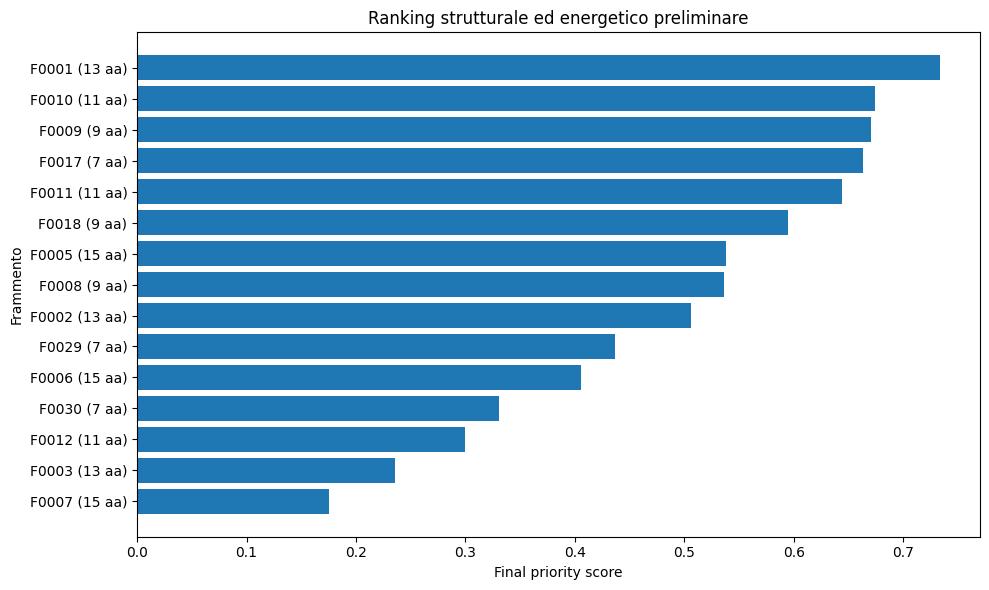

In [17]:
plot_df = ranking.sort_values(
    "final_priority_score",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["fragment_id"] + " (" + plot_df["length"].astype(str) + " aa)",
    plot_df["final_priority_score"],
)
plt.xlabel("Final priority score")
plt.ylabel("Frammento")
plt.title("Ranking strutturale ed energetico preliminare")
plt.tight_layout()
plt.savefig(
    RANKING_DIR / "short_peptide_final_ranking.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

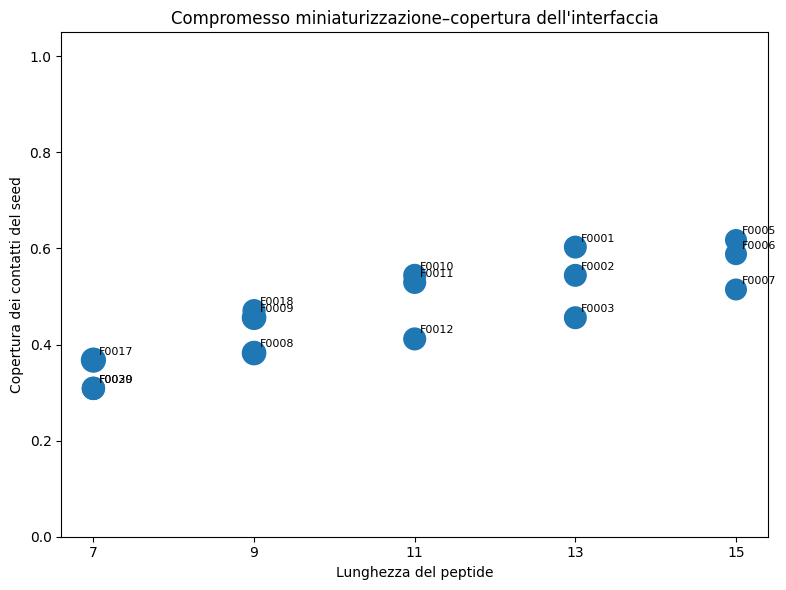

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(
    ranking["length"],
    ranking["seed_residue_contact_coverage"],
    s=80 + 300 * ranking["hotspot_density"],
)
for row in ranking.itertuples(index=False):
    plt.annotate(
        row.fragment_id,
        (row.length, row.seed_residue_contact_coverage),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )
plt.xlabel("Lunghezza del peptide")
plt.ylabel("Copertura dei contatti del seed")
plt.title("Compromesso miniaturizzazione–copertura dell'interfaccia")
plt.xticks(sorted(ranking["length"].unique()))
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(
    RANKING_DIR / "length_vs_seed_contact_coverage.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 18. Pannello raccomandato per il passaggio successivo

I primi cinque frammenti clash-free vengono proposti per:

- preparazione strutturale più accurata;
- rilassamento;
- docking guidato;
- confronto FoldX/Rosetta;
- eventuale generazione di varianti.


In [19]:
recommended = ranking[
    ranking["recommended_for_next_stage"]
].copy()

recommended_columns = [
    "structural_rank",
    "fragment_id",
    "sequence",
    "start_resseq",
    "end_resseq",
    "length",
    "n_hotspots",
    "hotspot_positions",
    "n_residue_contacts_4p5A",
    "seed_residue_contact_coverage",
    "residue_contacts_per_residue",
    "peptide_contact_residue_fraction",
    "min_interchain_distance_A",
    "n_severe_clashes_below_2p0A",
    "foldx_interaction_energy_kcal_mol",
    "final_priority_score",
    "complex_pdb",
]

recommended_columns = [
    c for c in recommended_columns if c in recommended.columns
]

display(recommended[recommended_columns])

,structural_rank,fragment_id,sequence,start_resseq,end_resseq,length,n_hotspots,hotspot_positions,n_residue_contacts_4p5A,seed_residue_contact_coverage,residue_contacts_per_residue,peptide_contact_residue_fraction,min_interchain_distance_A,n_severe_clashes_below_2p0A,foldx_interaction_energy_kcal_mol,final_priority_score,complex_pdb
0,1,F0001,YIGERCQYRDLKW,37,49,13,7,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,41,0.602941,3.153846,0.923077,2.602119,0,-5.150880,0.733518,outputs/short_peptide_structural_ranking/native_fragment_complexes/F0001_BD_D37-49.pdb
1,2,F0010,IGERCQYRDLK,38,48,11,6,D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,37,0.544118,3.363636,0.909091,2.602119,0,-2.944400,0.674343,outputs/short_peptide_structural_ranking/native_fragment_complexes/F0010_BD_D38-48.pdb
2,3,F0009,GERCQYRDL,39,47,9,6,D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,31,0.455882,3.444444,0.888889,2.602119,0,-0.807793,0.670994,outputs/short_peptide_structural_ranking/native_fragment_complexes/F0009_BD_D39-47.pdb
3,4,F0017,RCQYRDL,41,47,7,5,D:R41;D:Q43;D:Y44;D:R45;D:L47,25,0.367647,3.571429,0.857143,2.602119,0,-2.026120,0.663598,outputs/short_peptide_structural_ranking/native_fragment_complexes/F0017_BD_D41-47.pdb
4,5,F0011,GERCQYRDLKW,39,49,11,6,D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,36,0.529412,3.272727,0.909091,2.602119,0,-2.648450,0.644423,outputs/short_peptide_structural_ranking/native_fragment_complexes/F0011_BD_D39-49.pdb


## 19. Esportazione


In [20]:
SELECTED_CSV = RANKING_DIR / "selected_fragments_for_structural_analysis.csv"
STRUCTURAL_CSV = RANKING_DIR / "native_structural_metrics.csv"
FINAL_RANKING_CSV = RANKING_DIR / "short_peptide_structural_energetic_ranking.csv"
RECOMMENDED_CSV = RANKING_DIR / "recommended_fragments_for_next_stage.csv"
FOLDX_RUNS_CSV = RANKING_DIR / "foldx_run_status.csv"
METADATA_JSON = RANKING_DIR / "ranking_metadata.json"

selected.to_csv(SELECTED_CSV, index=False)
structural_metrics.to_csv(STRUCTURAL_CSV, index=False)
ranking.to_csv(FINAL_RANKING_CSV, index=False)
recommended.to_csv(RECOMMENDED_CSV, index=False)

if not foldx_runs.empty:
    foldx_runs.to_csv(FOLDX_RUNS_CSV, index=False)

metadata = {
    "pdb_id": PDB_ID,
    "pdb_path": str(PDB_PATH),
    "receptor_chain": RECEPTOR_CHAIN,
    "peptide_chain": PEPTIDE_CHAIN,
    "atom_contact_cutoff_A": ATOM_CONTACT_CUTOFF_A,
    "close_contact_cutoff_A": CLOSE_CONTACT_CUTOFF_A,
    "severe_clash_cutoff_A": SEVERE_CLASH_CUTOFF_A,
    "selection": {
        "prefer_within_original_seed": PREFER_WITHIN_ORIGINAL_SEED,
        "top_per_length": TOP_PER_LENGTH,
        "max_selected_fragments": MAX_SELECTED_FRAGMENTS,
        "required_lengths": REQUIRED_LENGTHS,
    },
    "n_library_fragments": int(len(library)),
    "n_selected_fragments": int(len(selected)),
    "n_recommended_fragments": int(len(recommended)),
    "foldx_available": bool(FOLDX_AVAILABLE),
    "foldx_executable": FOLDX_EXECUTABLE,
    "foldx_automatic_run_requested": bool(RUN_FOLDX_IF_AVAILABLE),
    "interpretation_warning": (
        "Fragments are evaluated in their native extracted PDB pose. "
        "The ranking does not prove autonomous folding, binding affinity, "
        "or inhibitory activity."
    ),
}

METADATA_JSON.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

for path in [
    SELECTED_CSV,
    STRUCTURAL_CSV,
    FINAL_RANKING_CSV,
    RECOMMENDED_CSV,
    METADATA_JSON,
    FOLDX_SCRIPT,
]:
    print("Salvato:", path.resolve())

print("Complessi PDB:", COMPLEX_DIR.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/selected_fragments_for_structural_analysis.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_structural_metrics.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/short_peptide_structural_energetic_ranking.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/recommended_fragments_for_next_stage.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/ranking_metadata.json
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/run_foldx_analysecomplex.sh
Complessi PDB: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_structural_ranking/native_fragment_complexes


## 20. Interpretazione finale

Il risultato principale è:

```text
outputs/short_peptide_structural_ranking/
    short_peptide_structural_energetic_ranking.csv
```

Il file:

```text
recommended_fragments_for_next_stage.csv
```

contiene il pannello ristretto da portare al passaggio successivo.

### Cosa dimostra il 02d

- quali frammenti conservano più contatti nativi;
- quali hanno maggiore densità di contatto;
- quali coprono meglio l'interfaccia del seed;
- quali non mostrano clash geometrici nella posa cristallografica;
- quali hanno, quando disponibile, uno score FoldX più favorevole.

### Cosa non dimostra

- che il peptide isolato mantenga il folding;
- che resti nella posa nativa;
- che leghi spontaneamente la catena B;
- che sia stabile in soluzione;
- che funzioni come inibitore.

Il passaggio seguente dovrà effettuare rilassamento e docking guidato dei frammenti raccomandati.
